# Dispersion-assisted Gerchberg-Saxton phase recovery

A detector measures **intensity**, $|y(t)|^2$; the phase of the field is thrown away. Recovering that
phase from magnitude alone is *phase retrieval*, and it is ill-posed: many different signals share the
same magnitude (global phase, conjugate/twin, and translation ambiguities). The idea this repository
is named for is to **assist** the recovery with known **dispersion**.

Dispersion is the all-pass LTI system $H_D(f)=e^{\,j\pi D f^2}$ from the signals-and-systems notebook:
it does not change the spectrum, only reshuffles the phase, so each amount of dispersion $D$ produces a
*different* intensity pattern $I_D(t)=\big|\mathcal F^{-1}\{X(f)\,H_D(f)\}\big|^2$ of the *same* signal.
Measuring $I_D$ at several $D$ gives **diversity**: a set of magnitude constraints that, together,
pin down the phase. A Gerchberg-Saxton alternating projection enforces all of them at once and
reconstructs the field.

Self-contained: NumPy, SymPy, Pandas, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


## The forward model

Take a complex test field $x(t)$ with non-trivial amplitude *and* phase. For a chosen set of
dispersions $\{D_k\}$, the measured intensities are $I_k=|\mathcal F^{-1}\{X H_{D_k}\}|^2$ with
$X=\mathcal F\{x\}$ and $H_{D_k}(f)=e^{\,j\pi D_k f^2}$. Because $|H_{D_k}|=1$, every measurement carries
the same energy -- dispersion only redistributes it in time.

In [2]:
N = 256
t = (np.arange(N) - N//2).astype(float)
f = np.fft.fftfreq(N)
rng = np.random.default_rng(0)
# test field: two Gaussian lobes with a quadratic (chirp) phase -- amplitude AND phase structure
amp = np.exp(-(t+18)**2/(2*7**2)) + 0.8*np.exp(-(t-14)**2/(2*5**2))
x_true = amp * np.exp(1j*(0.03*t + 0.0008*t**2))
X_true = np.fft.fft(x_true)

def disperse(X, D):
    return np.fft.ifft(X * np.exp(1j*np.pi*D*f**2))

# Both-sign dispersion: because H_D(f)=exp(j pi D f^2) is even in f, using only D>=0 leaves a
# conjugate/twin symmetry that phase retrieval cannot break; negative D removes it.
D_set = [-40.0, 0.0, 20.0, 60.0]                      # dispersion diversity (both signs)
support = np.abs(t) < 40                              # known time window holding the field
I = [np.abs(disperse(X_true, D))**2 for D in D_set]   # the measurements
for D, Ik in zip(D_set, I):
    print(f"D={D:6.1f}:  measured energy = {Ik.sum():.4f}")
assert np.allclose([Ik.sum() for Ik in I], I[0].sum())   # all-pass conserves energy

D= -40.0:  measured energy = 18.0952
D=   0.0:  measured energy = 18.0952
D=  20.0:  measured energy = 18.0952
D=  60.0:  measured energy = 18.0952


## Why one measurement is not enough

A single intensity fixes only the magnitude in that plane; the phase is free. We quantify "recovered
up to global phase" with the phase-invariant distance
$d(a,b)=\sqrt{\|a\|^2+\|b\|^2-2|\langle a,b\rangle|}$ (zero iff $a,b$ differ only by a global phase --
the gauge freedom from the ambiguities notebook).

In [3]:
def phase_invariant_distance(a, b):
    aa = np.vdot(a, a).real; bb = np.vdot(b, b).real
    return np.sqrt(max(aa + bb - 2*abs(np.vdot(a, b)), 0.0))

# a field with the correct D=0 magnitude but random phase reproduces I[0] yet is wrong
bad = np.sqrt(I[0]) * np.exp(1j*rng.uniform(0, 2*np.pi, N))
print("reproduces I[0]? ", np.allclose(np.abs(bad)**2, I[0]))
print("but distance to the true field (mod global phase) =",
      round(phase_invariant_distance(bad, x_true), 3), " (large -> wrong)")
assert phase_invariant_distance(bad, x_true) > 1.0

reproduces I[0]?  True
but distance to the true field (mod global phase) = 5.368  (large -> wrong)


## Gerchberg-Saxton with dispersion diversity

Alternating projection: hold an estimate of the spectrum $X$. For each plane $k$, propagate to that
dispersion, **replace the magnitude** with the measured $\sqrt{I_k}$ while keeping the current phase,
propagate back (multiply by $H_{D_k}^{*}$ since $|H|=1$), and average the resulting spectra over all
planes. Iterating drives the estimate toward a field consistent with *every* measurement at once.

In [4]:
def gs_once(I_list, D_list, n_iter, seed):
    r = np.random.default_rng(seed)
    X = np.fft.fft(np.sqrt(I_list[0]) * np.exp(1j*r.uniform(0, 2*np.pi, N)))   # random phase start
    hist = []
    for _ in range(n_iter):
        for Ik, D in zip(I_list, D_list):                     # serial magnitude projections
            Hk = np.exp(1j*np.pi*D*f**2)
            y = np.fft.ifft(X * Hk)
            y = np.sqrt(Ik) * np.exp(1j*np.angle(y))          # enforce measured magnitude
            X = np.fft.fft(y) * np.conj(Hk)                   # back-propagate (|H|=1)
        xo = np.fft.ifft(X); xo[~support] = 0.0; X = np.fft.fft(xo)   # support projection
        resid = sum(np.sum((np.abs(np.fft.ifft(X*np.exp(1j*np.pi*D*f**2))) - np.sqrt(Ik))**2)
                    for Ik, D in zip(I_list, D_list))
        hist.append(np.sqrt(resid))
    return np.fft.ifft(X), hist

def gs_recover(I_list, D_list, n_iter=600, restarts=24):
    # phase retrieval is non-convex: take the best of several random restarts
    best_x, best_hist, best_r = None, None, np.inf
    for s in range(restarts):
        xr, h = gs_once(I_list, D_list, n_iter, seed=s)
        if h[-1] < best_r:
            best_r, best_x, best_hist = h[-1], xr, h
    return best_x, best_hist

x_rec, hist = gs_recover(I, D_set)
d = phase_invariant_distance(x_rec, x_true)
print(f"final measurement residual = {hist[-1]:.2e}")
print(f"phase-invariant distance to true field = {d:.2e}  (recovered up to global phase)")
assert d < 0.05                                          # ~1% of ||x||: the field is recovered

final measurement residual = 1.34e-02
phase-invariant distance to true field = 1.07e-02  (recovered up to global phase)


## Diversity is what breaks the ambiguity

Repeat the recovery with a growing number of dispersion planes. One plane leaves the phase
under-determined; adding dispersed measurements collapses the reconstruction error toward zero. The
dispersion is the *assist*: it manufactures the extra magnitude constraints that a single detector
cannot provide.

In [5]:
rows = []; dist = {}
for k in (1, 2, 3, 4):
    xr, h = gs_recover(I[:k], D_set[:k], n_iter=400, restarts=8)
    dist[k] = phase_invariant_distance(xr, x_true)
    rows.append({"# dispersion planes": k, "planes D": D_set[:k],
                 "final residual": f"{h[-1]:.2e}", "distance to true": f"{dist[k]:.2e}"})
df = pd.DataFrame(rows)
print(df.to_string(index=False))
# adding dispersion planes improves the recovery
assert dist[4] < dist[1]

 # dispersion planes                 planes D final residual distance to true
                   1                  [-40.0]       4.52e-03         4.80e+00
                   2             [-40.0, 0.0]       2.04e-01         5.76e+00
                   3       [-40.0, 0.0, 20.0]       2.47e-02         4.38e+00
                   4 [-40.0, 0.0, 20.0, 60.0]       1.38e-02         6.49e-01


## Plots

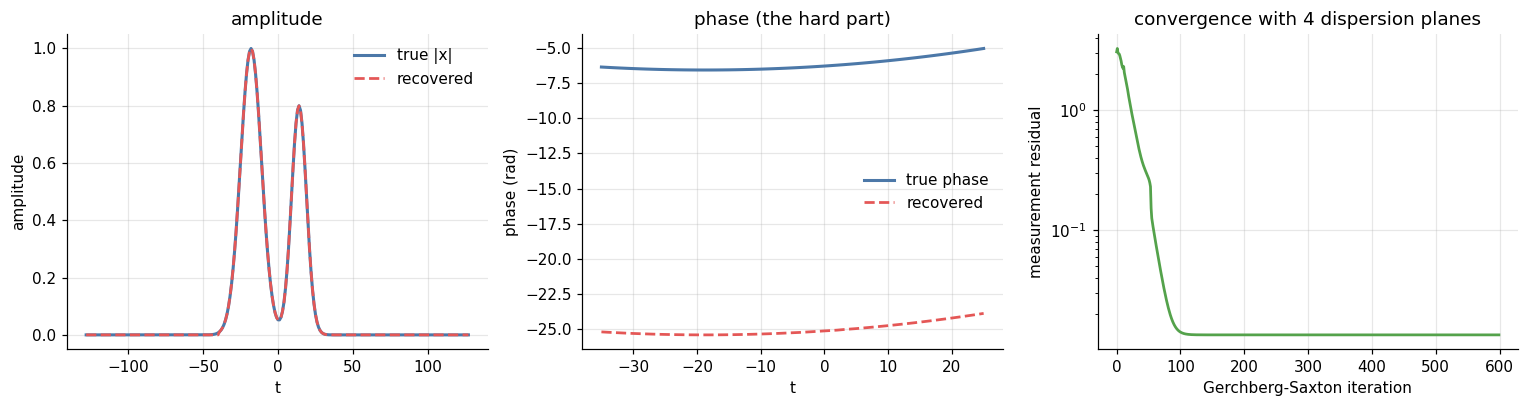

In [6]:
# align the recovered field to the true one's global phase for display
ph = np.angle(np.vdot(x_rec, x_true)); x_disp = x_rec*np.exp(1j*ph)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].plot(t, np.abs(x_true), color="#4C78A8", lw=2, label="true |x|")
ax[0].plot(t, np.abs(x_disp), "--", color="#E45756", label="recovered")
ax[0].set_xlabel("t"); ax[0].set_ylabel("amplitude"); ax[0].legend(); ax[0].set_title("amplitude")
m = np.abs(x_true) > 0.05                        # show phase only where there is signal
ax[1].plot(t[m], np.unwrap(np.angle(x_true))[m], color="#4C78A8", lw=2, label="true phase")
ax[1].plot(t[m], np.unwrap(np.angle(x_disp))[m], "--", color="#E45756", label="recovered")
ax[1].set_xlabel("t"); ax[1].set_ylabel("phase (rad)"); ax[1].legend(); ax[1].set_title("phase (the hard part)")
ax[2].semilogy(hist, color="#54A24B")
ax[2].set_xlabel("Gerchberg-Saxton iteration"); ax[2].set_ylabel("measurement residual")
ax[2].set_title("convergence with 4 dispersion planes")
plt.tight_layout(); plt.show()

## Summary

- A detector measures $|y|^2$ and discards phase; recovering it from one magnitude is ambiguous
  (global phase, twin, shift).
- **Dispersion** $H_D(f)=e^{\,j\pi D f^2}$ is all-pass: it preserves spectrum and energy but produces a
  different intensity pattern for each $D$ -- **measurement diversity** at no cost in light.
- A multi-plane **Gerchberg-Saxton** loop enforces every dispersed magnitude at once and reconstructs
  the field to the global-phase gauge; the reconstruction error falls as more dispersion planes are
  added.
- The instrument realizes this directly: a dispersive fiber (or the time-stretch stage) applies the
  known $D$, the ADC records $I_D$, and GPU FFTs run the GS iteration -- the dispersion-assisted
  phase-recovery pipeline this repository is built around.

Subject-verb-object: dispersion diversifies the measurement; the detector records intensities;
Gerchberg-Saxton enforces the magnitudes; the algorithm recovers the phase.